<a href="https://colab.research.google.com/github/cenna-alias/test/blob/main/8_Random_Forest_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Random Forest Classifier - Complete Teaching Notebook
Using Iris Dataset with detailed comments.

In [ ]:
# STEP 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# STEP 2: Load built-in Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['target'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
# STEP 3: Explore dataset
print('Shape:', df.shape)
print('\nFeatures:', iris.feature_names)
print('\nClasses:', iris.target_names)
df.describe()

Shape: (150, 5)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Classes: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [ ]:
# STEP 4: Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(120, 4) (30, 4)


In [ ]:
# STEP 5: Create Random Forest Model
# n_estimators = number of trees
# max_depth = maximum depth of each tree
model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=5,
    random_state=42
)
model.fit(X_train, y_train)
print('Model trained successfully')

Model trained successfully


In [ ]:
# STEP 6: Predictions
y_pred = model.predict(X_test)
print(y_pred[:10])

[0 2 1 1 0 1 0 0 2 1]


In [ ]:
# STEP 7: Accuracy
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy =', accuracy)

Accuracy = 0.9333333333333333


In [ ]:
# STEP 8: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [ ]:
# STEP 9: Classification Report
print(classification_report(y_test, y_pred, target_names=iris.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [ ]:
# STEP 10: Feature Importance
importance = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': model.feature_importances_
})
importance = importance.sort_values('Importance', ascending=False)
print(importance)

             Feature  Importance
3   petal width (cm)    0.438141
2  petal length (cm)    0.431641
0  sepal length (cm)    0.115972
1   sepal width (cm)    0.014246


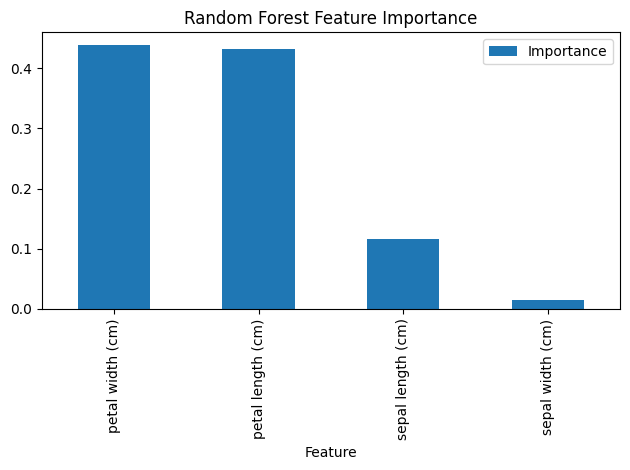

In [ ]:
# STEP 11: Visualize Feature Importance
importance.plot(x='Feature', y='Importance', kind='bar')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

In [ ]:
# STEP 12: Predict a new flower
sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)
print('Predicted Class:', iris.target_names[prediction[0]])

Predicted Class: setosa
